In [ ]:
import sys
sys.path.insert(1, "/mnt/c/Users/PC/Desktop/wikolego-repository/ai-path/projects/spaceship-titanic/src")
import config
import pandas as pd

In [3]:
df = pd.read_csv(config.TRAINING_FILE)
df = df.fillna(-1)
df

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,9276_01,Europa,False,A/98/P,55 Cancri e,41.0,True,0.0,6819.0,0.0,1643.0,74.0,Gravior Noxnuther,False
8689,9278_01,Earth,True,G/1499/S,PSO J318.5-22,18.0,False,0.0,0.0,0.0,0.0,0.0,Kurta Mondalley,False
8690,9279_01,Earth,False,G/1500/S,TRAPPIST-1e,26.0,False,0.0,0.0,1872.0,1.0,0.0,Fayey Connon,True
8691,9280_01,Europa,False,E/608/S,55 Cancri e,32.0,False,0.0,1049.0,0.0,353.0,3235.0,Celeon Hontichre,False


In [61]:
print(df.groupby(["Transported"])["Transported"].count())

Transported
False    4315
True     4378
Name: Transported, dtype: int64


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

In [71]:
# x_data = df["Age"].values
# x_data = df["Age"].unique()
x_data = list(range(10, 20))
print(x_data)

df2 = df.loc[(df["Age"] >= 10) & (df["Age"] < 20), "Age"]
df3 = df.loc[df["Age"].isin(x_data), "Age"]
print(df2)
print(df3)
# print(df2.loc[df2["Age"] >= 10, ["Age", "Transported"]])

[10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
4       16.0
9       14.0
20      14.0
24      10.0
29      15.0
        ... 
8663    13.0
8670    19.0
8671    16.0
8674    13.0
8689    18.0
Name: Age, Length: 1479, dtype: float64
4       16.0
9       14.0
20      14.0
24      10.0
29      15.0
        ... 
8663    13.0
8670    19.0
8671    16.0
8674    13.0
8689    18.0
Name: Age, Length: 1479, dtype: float64


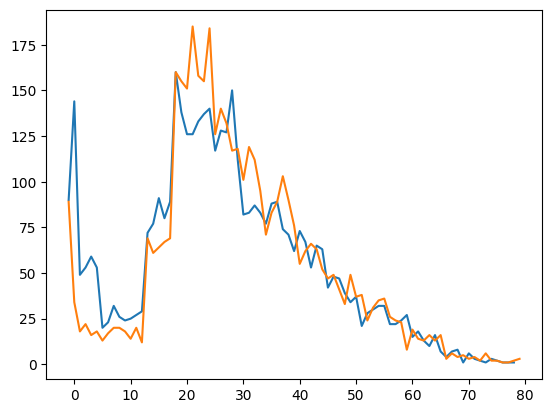

In [129]:
# y_data_1 = df.loc[df["Transported"] == True, "Age"].reset_index().groupby("Age")["Age"].count()

data_1 = df.loc[df["Transported"] == True, :].groupby("Age")["Age"].count().reset_index(name="count")
data_2 = df.loc[df["Transported"] == False, :].groupby("Age")["Age"].count().reset_index(name="count")
# groupby("Age")["Age"].count()
# y_data = df.loc[df["Transported"] == False, "Age"].groupby("Age")["Age"].count()

# print(type(x_data_1))
# print(type(y_data_1))

plt.plot(data_1["Age"], data_1["count"])
plt.plot(data_2["Age"], data_2["count"])
plt.show()

In [130]:
new_data = df.groupby(["Transported", "Age"])["PassengerId"].count().reset_index(name="count")
new_data

,Transported,Age,count
0,False,-1.0,89
1,False,0.0,34
2,False,1.0,18
3,False,2.0,22
4,False,3.0,16
...,...,...,...
156,True,74.0,3
157,True,75.0,2
158,True,76.0,1
159,True,77.0,1


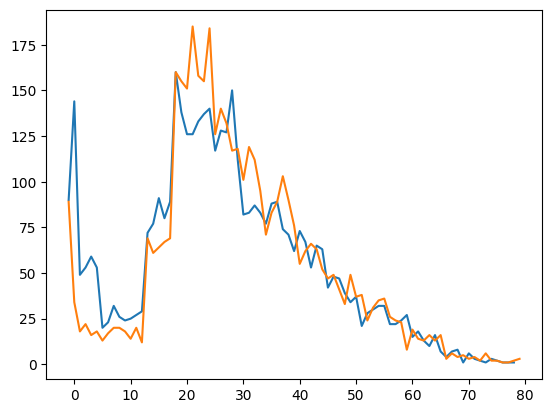

In [131]:
data_1 = new_data.loc[new_data["Transported"] == True, :]
data_2 = new_data.loc[new_data["Transported"] == False, :]

plt.plot(data_1["Age"], data_1["count"])
plt.plot(data_2["Age"], data_2["count"])

In [5]:
df[["Cabin_1", "Cabin_2", "Cabin_3"]] = df["Cabin"].str.split("/", expand=True)
df = df.drop(axis=1, columns=["Cabin"])
df

,PassengerId,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported,Cabin_1,Cabin_2,Cabin_3
0,0001_01,Europa,False,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False,B,0,P
1,0002_01,Earth,False,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True,F,0,S
2,0003_01,Europa,False,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False,A,0,S
3,0003_02,Europa,False,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False,A,0,S
4,0004_01,Earth,False,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True,F,1,S
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,9276_01,Europa,False,55 Cancri e,41.0,True,0.0,6819.0,0.0,1643.0,74.0,Gravior Noxnuther,False,A,98,P
8689,9278_01,Earth,True,PSO J318.5-22,18.0,False,0.0,0.0,0.0,0.0,0.0,Kurta Mondalley,False,G,1499,S
8690,9279_01,Earth,False,TRAPPIST-1e,26.0,False,0.0,0.0,1872.0,1.0,0.0,Fayey Connon,True,G,1500,S
8691,9280_01,Europa,False,55 Cancri e,32.0,False,0.0,1049.0,0.0,353.0,3235.0,Celeon Hontichre,False,E,608,S


In [6]:
# new_data = df.groupby(["Transported", "VIP", "Cabin_1"])["PassengerId"].count().reset_index(name="count")
new_data = df.groupby(["Transported", "Cabin_1"])["PassengerId"].count().reset_index(name="count")
new_data

,Transported,Cabin_1,count
0,False,A,129
1,False,B,207
2,False,C,239
3,False,D,271
4,False,E,563
5,False,F,1565
6,False,G,1238
7,False,T,4
8,True,A,127
9,True,B,572


In [7]:
new_data = df.groupby(["FoodCourt", "Transported"])["PassengerId"].count().reset_index(name="count")
new_data

,FoodCourt,Transported,count
0,-1.0,False,84
1,-1.0,True,99
2,0.0,False,2232
3,0.0,True,3224
4,1.0,False,90
...,...,...,...
1793,21066.0,True,1
1794,26830.0,True,1
1795,27071.0,True,1
1796,27723.0,True,1


/home/wikolego/miniconda3/envs/ml/lib/python3.7/site-packages/ipykernel_launcher.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  after removing the cwd from sys.path.


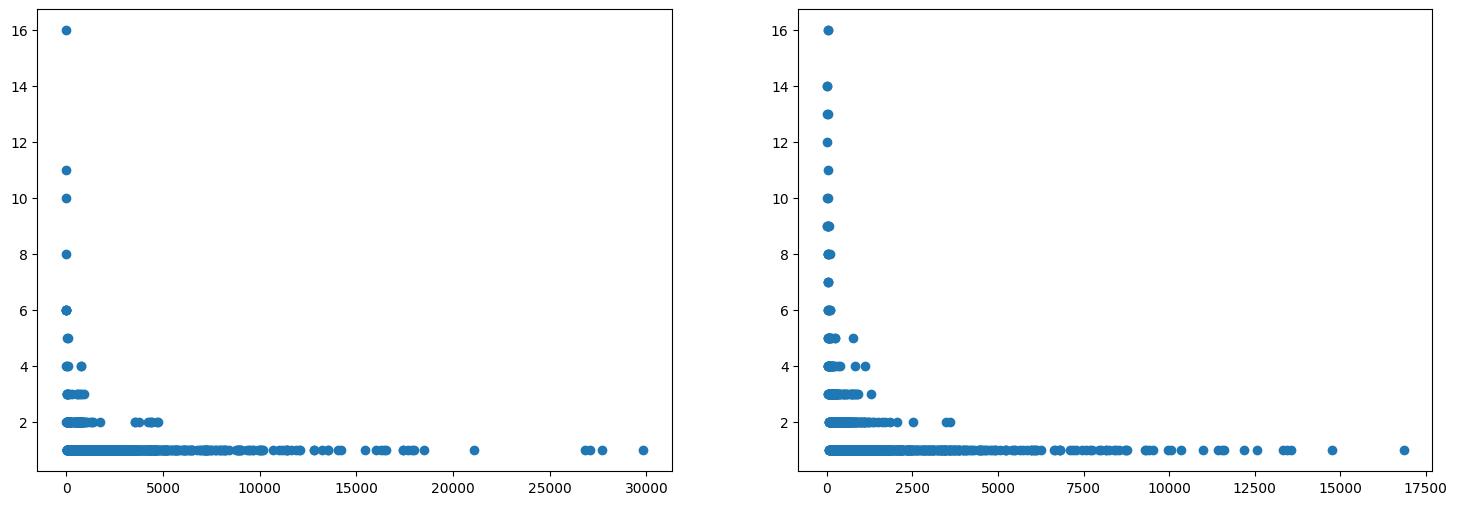

In [28]:
max_count = 20
data_1 = new_data.loc[(new_data["Transported"] == True) & (new_data["count"] < max_count), :]
data_2 = new_data.loc[(new_data["Transported"] == False) & (new_data["count"] < max_count), :]
data_1["FoodCourt"] = data_1["FoodCourt"]

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(18, 6))

ax[0].scatter(data_1["FoodCourt"], data_1["count"])
ax[1].scatter(data_2["FoodCourt"], data_2["count"])

plt.show()